<a href="https://colab.research.google.com/github/Anastasia-Dok/OOP_Doktor/blob/master/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF
import math


import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
#ЗАДАНИЕ 1
#μ = 175 см, σ = 8 см

mu = 175           # среднее значение
sigma = 8          # стандартное отклонение
n = 50             # размер выборки

# Генерируем выборку из нормального распределения
norm_rv = stats.norm(loc=mu, scale=sigma)
sample = norm_rv.rvs(n, random_state=1)
print(sample)

# Расчет выборочного среднего
sample_mean = np.mean(sample)
# Расчет выборочного стандартного отклонения
# ddof=1 для несмещенной оценки (n-1 в знаменателе)
sample_std = np.std(sample, ddof=1)
print(f"Выборочное среднее: {sample_mean:.2f} см")
print(f"Выборочное стандартное отклонение: {sample_std:.2f} см")

#E = σ/n^(1/2) = 8/корень(50) = 1.1314
#Z(1-0.95) =Z(0.975) = 1.96

standart_error = sigma / math.sqrt(50)
print(standart_error)
norm1 = stats.norm(1,0)
z_val = norm1.ppf(1-0.95)

borders = standart_error*z_val

leftB = sample_mean - borders
rightB = sample_mean + borders
print(f"Доверительный интервал: от {leftB:.2f} до {rightB:.2f} ")

[187.99476291 170.10594869 170.77462598 166.41625102 181.92326103
 156.58769042 188.95849411 168.91034479 177.55231277 173.005037
 186.6968635  158.51887432 172.42066237 171.92756516 184.07015554
 166.20086986 173.62057434 167.97713266 175.33770997 179.66252171
 166.19504658 184.15778968 182.21272576 179.01995471 182.20684759
 169.53017713 174.0168782  167.51384453 172.85689536 179.24284373
 169.46671399 171.82597179 169.5026184  168.23835487 169.63003095
 174.89868321 166.06151721 176.87532558 188.27841742 180.93635328
 173.46531558 167.89896829 169.02273365 188.53963681 175.40646204
 169.90403483 176.52732388 191.80204109 175.96127162 179.93762488]
Выборочное среднее: 174.80 см
Выборочное стандартное отклонение: 7.84 см
1.131370849898476
Доверительный интервал: от nan до nan 


In [32]:
print("РАСЧЕТ С ПОМОЩЬЮ SCIPY.STATS:")
ci_norm = stats.norm.interval(confidence=0.95, loc=sample_mean, scale=standart_error)
print(f"norm.interval(): ({ci_norm[0]:.2f}, {ci_norm[1]:.2f}) см")

РАСЧЕТ С ПОМОЩЬЮ SCIPY.STATS:
norm.interval(): (172.58, 177.01) см


In [33]:
#ДИ при неизвестном стандартном отклонении
df = n - 1
alpha = 0.05
t_quantile = stats.t.ppf(1 - alpha/2, df)
print(f"\nКвантиль t-распределения: {t_quantile:.4f}")

error_marg = t_quantile * (sample_std / np.sqrt(n))
l = sample_mean - error_marg
r = sample_mean + error_marg

print(f"[{l:.4f}, {r:.4f}]")


Квантиль t-распределения: 2.0096
[172.5691, 177.0227]


In [34]:
# Расчет 95% доверительного интервала с помощью stats.t.interval()
ci_t = stats.t.interval(confidence=0.95, df=n-1, loc=sample_mean, scale=stats.sem(sample))
print(f"\n95% доверительный интервал (t-распределение):")
print(f"({ci_t[0]:.4f}, {ci_t[1]:.4f}) см")


95% доверительный интервал (t-распределение):
(172.5691, 177.0227) см


[]

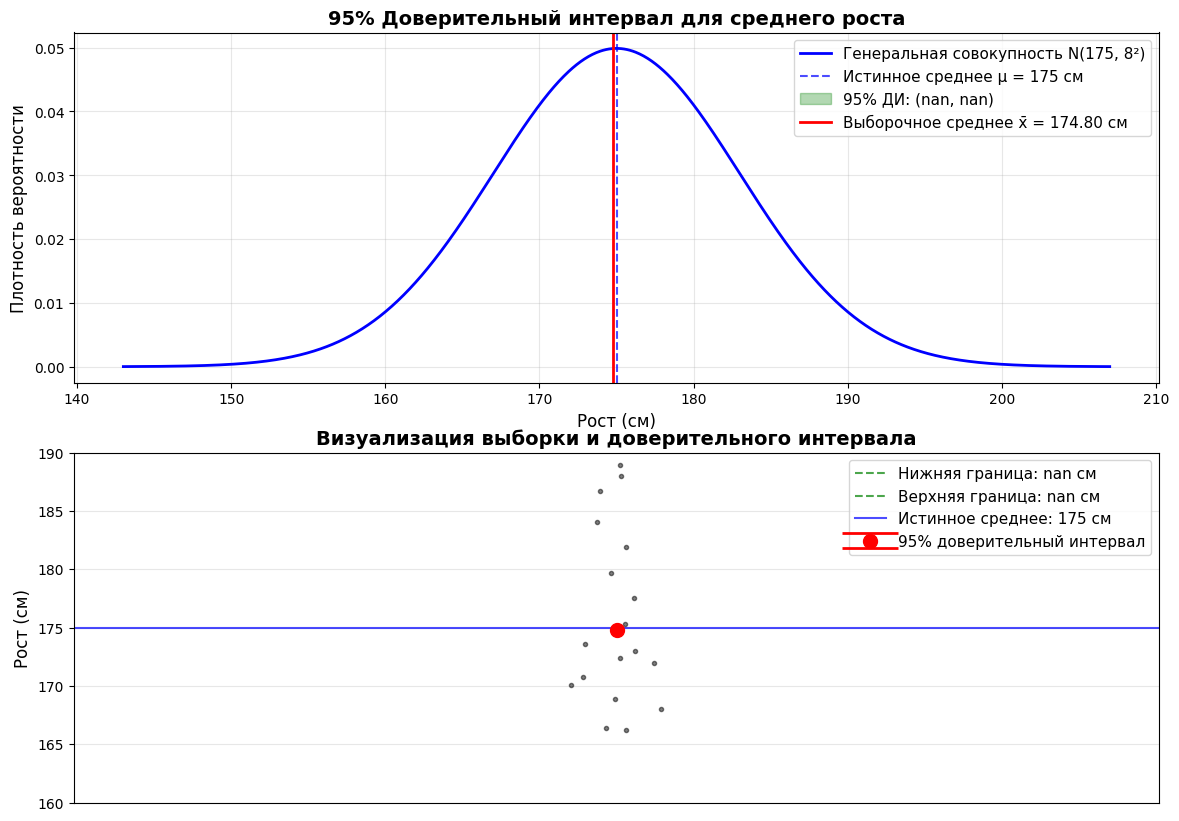

In [35]:
# Создаем график
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))


x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

ax1.plot(x, y, 'b-', linewidth=2, label=f'Генеральная совокупность N({mu}, {sigma}²)')
ax1.axvline(mu, color='blue', linestyle='--', alpha=0.7, label=f'Истинное среднее μ = {mu} см')

# Зона доверительного интервала
x_fill = np.linspace(leftB, rightB, 100)
y_fill = stats.norm.pdf(x_fill, mu, sigma)
ax1.fill_between(x_fill, y_fill, alpha=0.3, color='green',
                 label=f'95% ДИ: ({leftB:.2f}, {rightB:.2f})')

ax1.axvline(sample_mean, color='red', linestyle='-', linewidth=2,
            label=f'Выборочное среднее x̄ = {sample_mean:.2f} см')
ax1.axvline(leftB, color='green', linestyle=':', alpha=0.7)
ax1.axvline(rightB, color='green', linestyle=':', alpha=0.7)

ax1.set_xlabel('Рост (см)', fontsize=12)
ax1.set_ylabel('Плотность вероятности', fontsize=12)
ax1.set_title('95% Доверительный интервал для среднего роста',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)


ax2.errorbar(1, sample_mean, yerr=borders, fmt='o', color='red',
             markersize=10, capsize=20, capthick=2, linewidth=3,
             label='95% доверительный интервал')

# Показываем границы интервала
ax2.axhline(y=leftB, color='green', linestyle='--', alpha=0.7,
            label=f'Нижняя граница: {leftB:.2f} см')
ax2.axhline(y=rightB, color='green', linestyle='--', alpha=0.7,
            label=f'Верхняя граница: {rightB:.2f} см')
ax2.axhline(y=mu, color='blue', linestyle='-', alpha=0.7,
            label=f'Истинное среднее: {mu} см')

# Отображаем отдельные точки выборки
for i, height in enumerate(sample[:20]):  # Покажем первые 20 точек для наглядности
    ax2.plot(1 + np.random.normal(0, 0.02), height, 'ko', alpha=0.5, markersize=3)

ax2.set_xlim(0.5, 1.5)
ax2.set_ylim(160, 190)
ax2.set_ylabel('Рост (см)', fontsize=12)
ax2.set_title('Визуализация выборки и доверительного интервала', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xticks([])

In [36]:
know = rightB - leftB
UNKNOW = r-l
print(f"\nСравнение ширины доверительных интервалов:")
print(f"Разница: {UNKNOW-know:.4f} см")


Сравнение ширины доверительных интервалов:
Разница: nan см


In [37]:
#2 задание
#μ=22, σ=3
mu2 = 22           # среднее значение
sigma2 = 3         # стандартное отклонение
m = 30             # размер выборки
n_outliers = 3  # количество выбросов
outlier_magnitude = 5  # величина выброса

temperatures = np.random.normal(mu2, sigma2, m)
print(temperatures)
t_copy = temperatures.copy()

outlier_indices = np.random.choice(m, n_outliers, replace=False)
print(f"Дни с выбросами: {outlier_indices + 1}")

for idx in outlier_indices:
    # Случайно выбираем направление выброса (+ или -)
    direction = np.random.choice([-1, 1])
    t_copy[idx] += direction * outlier_magnitude

print(f"\nРаспределение с выбросами: {t_copy}")
#print(f"Размер: {t_copy.size}")

[19.76489805 26.02975966 21.33160334 24.08910653 21.46335969 22.85498949
 21.98926943 24.76094561 26.97237231 16.57760857 29.24343644 19.31870165
 20.25340035 18.81646831 24.67810114 22.8096317  25.09903376 20.6525788
 17.53301426 25.50035116 25.43004618 18.58670601 17.12830066 22.84722348
 20.89932431 18.04711974 22.90913025 23.97959714 17.51872368 17.46265396]
Дни с выбросами: [ 2  6 12]

Распределение с выбросами: [19.76489805 21.02975966 21.33160334 24.08910653 21.46335969 27.85498949
 21.98926943 24.76094561 26.97237231 16.57760857 29.24343644 24.31870165
 20.25340035 18.81646831 24.67810114 22.8096317  25.09903376 20.6525788
 17.53301426 25.50035116 25.43004618 18.58670601 17.12830066 22.84722348
 20.89932431 18.04711974 22.90913025 23.97959714 17.51872368 17.46265396]


In [38]:
# Расчет выборочного среднего
sample_mean_t = np.mean(t_copy)
# Расчет выборочного стандартного отклонения
# ddof=1 для несмещенной оценки (n-1 в знаменателе)
sample_std_t = np.std(t_copy, ddof=1)
print(f"Выборочное среднее: {sample_mean_t:.4f} см")
print(f"Выборочное стандартное отклонение: {sample_std_t:.4f} см")
df = m - 1
alpha = 0.05
t_quantile2 = stats.t.ppf(1 - alpha/2, df)
print(f"\nКвантиль t-распределения: {t_quantile2:.4f}")

error_marg2 = t_quantile2 * (sample_std_t / np.sqrt(m))
l2 = sample_mean_t - error_marg2
r2 = sample_mean_t + error_marg2

print(f"ДИ:\n[{l2:.4f}, {r2:.4f}]")

Выборочное среднее: 21.9849 см
Выборочное стандартное отклонение: 3.4223 см

Квантиль t-распределения: 2.0452
ДИ:
[20.7070, 23.2628]


In [39]:
import numpy as np

def detect_outliers_iqr(data , multiplier=1.5):
    data = np.array(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")

    iqr = q3 - q1
    print(f"IQR: {iqr}")

    lower_bound = q1 - (multiplier * iqr)
    upper_bound = q3 + (multiplier * iqr)
    print(lower_bound)
    print(upper_bound)
    return data[(data >= lower_bound) & (data <= upper_bound)]

clean_d = detect_outliers_iqr(t_copy)
print(f"Данные после удаления выбросов: {clean_d}")
print(f"Размер после удаления: {clean_d.size}")

Q1: 19.053575748760174
Q3: 24.588251263626333
IQR: 5.534675514866159
10.751562476460936
32.89026453592557
Данные после удаления выбросов: [19.76489805 21.02975966 21.33160334 24.08910653 21.46335969 27.85498949
 21.98926943 24.76094561 26.97237231 16.57760857 29.24343644 24.31870165
 20.25340035 18.81646831 24.67810114 22.8096317  25.09903376 20.6525788
 17.53301426 25.50035116 25.43004618 18.58670601 17.12830066 22.84722348
 20.89932431 18.04711974 22.90913025 23.97959714 17.51872368 17.46265396]
Размер после удаления: 30


In [40]:
#95% ДИ для средней температуры очищенных данных

confidence_level = 0.95
alpha = 1 - confidence_level

sample_mean_clean = np.mean(clean_d)
sample_std_clean = np.std(clean_d, ddof=1)
print(f"Выборочное среднее: {sample_mean_clean:.4f} см")
print(f"Выборочное стандартное отклонение: {sample_std_clean:.4f} см")
df_clean = clean_d.size - 1
t_quantile_clean = stats.t.ppf(1 - alpha/2, df_clean)
print(f"\nКвантиль t-распределения: {t_quantile_clean:.4f}")

error_cl = t_quantile_clean * (sample_std_clean / np.sqrt(clean_d.size ))

lower_cl = sample_mean_clean - error_cl
upper_cl = sample_mean_clean + error_cl

print(f"[{lower_cl:.2f}, {upper_cl:.2f}]")

Выборочное среднее: 21.9849 см
Выборочное стандартное отклонение: 3.4223 см

Квантиль t-распределения: 2.0452
[20.71, 23.26]


In [41]:
print(f"Разница средних: {sample_mean_clean - sample_mean_t}")
print(f"Разница стандартных отклонений: {sample_std_clean - sample_std_t}")
print(f"Разница ширины интервалов: {(upper_cl-lower_cl) - (r2-l2)}")

Разница средних: 0.0
Разница стандартных отклонений: 0.0
Разница ширины интервалов: 0.0


In [42]:
#Задание 3
s = 40 # размер выборки. минуты.
#параметры гамма распр
shape_g=2
scale_g=10

time_delivery = np.random.gamma(shape=shape_g, scale=scale_g, size=s)
print(time_delivery)

[13.03193386 52.70993584 64.33230836 17.7531152  29.60713803 10.89356465
 33.09926889 48.43577848 32.26073373 26.19479017 15.81081034  7.04824064
 10.7940363  16.89996899 29.75873359  0.6410972  28.62727214 15.46622629
 44.12478027 27.17886332 46.40723449  7.76115488  3.63550217 25.29205835
 17.85915159  1.97570999 28.78670589  8.90369828 31.50315196  7.40115683
 20.79617557 15.08279028 20.5766029  21.3256162  35.64115308 57.84923761
 26.1499272  22.45724132 13.12783717 38.60978107]



ОСНОВНЫЕ СТАТИСТИКИ:
Размер выборки: 40
Среднее время: 24.40 мин
Медиана: 21.89 мин
Стандартное отклонение: 15.40 мин
Минимум: 0.64 мин
Максимум: 64.33 мин


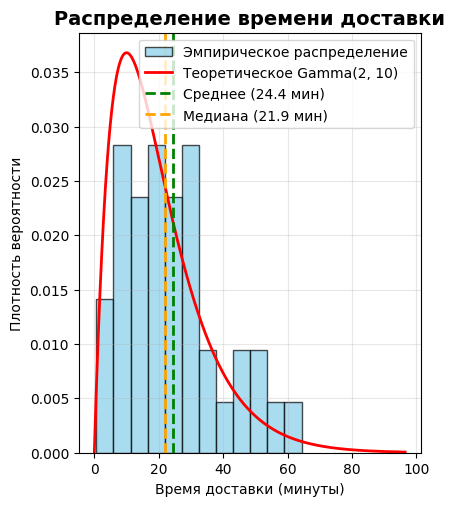

In [43]:
# Основные статистики
mean_time = np.mean(time_delivery)
median_time = np.median(time_delivery)
std_time = np.std(time_delivery, ddof=1)

print(f"\nОСНОВНЫЕ СТАТИСТИКИ:")
print(f"Размер выборки: {s}")
print(f"Среднее время: {mean_time:.2f} мин")
print(f"Медиана: {median_time:.2f} мин")
print(f"Стандартное отклонение: {std_time:.2f} мин")
print(f"Минимум: {np.min(time_delivery):.2f} мин")
print(f"Максимум: {np.max(time_delivery):.2f} мин")

# Теоретическое гамма-распределение
x = np.linspace(0, np.max(time_delivery) * 1.5, 1000)
theoretical_pdf = stats.gamma.pdf(x, a=shape_g, scale=scale_g)

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
plt.hist(time_delivery, bins=12, density=True, alpha=0.7, color='skyblue',
         edgecolor='black', label='Эмпирическое распределение')
plt.plot(x, theoretical_pdf, 'r-', linewidth=2,
         label=f'Теоретическое Gamma({shape_g}, {scale_g})')
plt.axvline(mean_time, color='green', linestyle='--', linewidth=2,
            label=f'Среднее ({mean_time:.1f} мин)')
plt.axvline(median_time, color='orange', linestyle='--', linewidth=2,
            label=f'Медиана ({median_time:.1f} мин)')
plt.xlabel('Время доставки (минуты)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение времени доставки', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

In [44]:
#бутстреп

n_bootstrap = 1000
confidence_level = 0.90
alpha = 1 - confidence_level

bootstrap_medians = np.zeros(n_bootstrap)
for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(time_delivery, size=s, replace=True)
    bootstrap_medians[i] = np.median(bootstrap_sample)

ci_basic_lower = np.percentile(bootstrap_medians, 100 * alpha/2) #5%
ci_basic_upper = np.percentile(bootstrap_medians, 100 * (1 - alpha/2)) #95%

print(f"  90% ДИ: ({ci_basic_lower:.4f}, {ci_basic_upper:.4f}) ")
print(f"  Ширина интервала: {ci_basic_upper - ci_basic_lower:.4f} ")

  90% ДИ: (17.3265, 27.9031) 
  Ширина интервала: 10.5765 


In [45]:
def stat_median_scipy(data, axis=0):
    return np.median(data, axis=axis)

#Базовый бутстреп
res_basic = stats.bootstrap((time_delivery,), statistic=stat_median_scipy,
    vectorized=False, confidence_level=0.90, n_resamples=1000,
    method='basic', random_state=111
)

#Ускоренный бутстреп BCa
res_bca = stats.bootstrap( (time_delivery,), statistic=stat_median_scipy, vectorized=False,
    confidence_level=0.90, n_resamples=1000, method='bca',
    random_state=111
)

print(f"\n БАЗОВЫЙ БУТСТРЕП :")
print(f"  90% доверительный интервал для медианы:")
print(f"  ({res_basic.confidence_interval.low:.4f}, {res_basic.confidence_interval.high:.4f}) мин")
print(f"  Ширина интервала: {res_basic.confidence_interval.high - res_basic.confidence_interval.low:.4f} мин")


print(f"\nУСКОРЕННЫЙ БУТСТРЕП:")
print(f"  90% доверительный интервал для медианы:")
print(f"  ({res_bca.confidence_interval.low:.4f}, {res_bca.confidence_interval.high:.4f}) мин")
print(f"  Ширина интервала: {res_bca.confidence_interval.high - res_bca.confidence_interval.low:.4f} мин")




 БАЗОВЫЙ БУТСТРЕП :
  90% доверительный интервал для медианы:
  (15.8798, 26.4563) мин
  Ширина интервала: 10.5765 мин

УСКОРЕННЫЙ БУТСТРЕП:
  90% доверительный интервал для медианы:
  (17.3265, 27.9031) мин
  Ширина интервала: 10.5765 мин
